In [3]:
""" Problem 8.4.3 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt, log10

Hp = .88
Hs = .1
wp = 6000/5000
#ws = 5000/5000 = 1
wp0 = 1/wp

jj = complex(0,1)

eps = sqrt(Hs**2/(1-Hs**2))
aa = sqrt((1/eps**2)*(1/(1-Hp**2)))
bb = 1 / np.arccosh(1/wp0)
n = np.arccosh(aa)*bb
print('aa = ',aa,' bb= ',bb)
print('n = ', n)

print('eps = ',eps)
alpha = 1/eps + sqrt(1 + 1/eps**2)
print('alpha = ',alpha)
a = 0.5*(alpha**(1/n)-alpha**(-1/n))
b = 0.5*(alpha**(1/n) + alpha**(-1/n))
print('a = ',a,' b = ',b)

aa =  20.9482645399098  bb=  1.6067806046012827
n =  6.000735549773726
eps =  0.10050378152592122
alpha =  19.949874371066194
a =  0.5197530379547687  b =  1.1270063089722306


p1 =  (250.00000000000006+0.9760160937952858j)  d1 =  [1, 0.007999878068109286, 1.5999756136218566e-05]
q1 =  (0.003999939034054643-1.56160194857492e-05j)
omega1 =  1.1547005383792515
K = 2.399963420432785e-08
[3.1999512272437135e-08, 0, 2.399963420432785e-08, 0]
[3.19995123e-08 3.19995123e-05 9.99987807e-03 1.00000000e+00]


<>:47: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_5868\2685152405.py:47: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


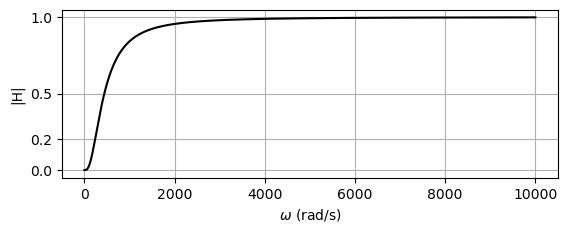

In [7]:
""" Pole at -180 deg """
p0 = a
d0 = [1,1/a]

""" Pole at -60 deg from -180 """
theta = np.deg2rad(60)
p1 = a*cos(theta) + jj*b*sin(theta)
q1 = 1/p1
d1 = [1,2*q1.real,(q1.real**2 + q1.imag**2)]
print('p1 = ',p1,' d1 = ',d1)
print('q1 = ', q1)

den = np.convolve(d0,d1)

""" zeros """
omega1 = 1/cos(1*np.pi/(2*3))
print('omega1 = ',omega1)
num = [0,1,0,omega1**2]

""" constant """
K = den[3]/num[3]
print('K =',K)
num = [0,K,0,K*omega1**2]

""" LPF to HPF """
numh = num[::-1]
denh = den[::-1]
print(numh)
print(denh)

""" Scale up """
a = 500
nums = [numh[0],a*numh[1],(a**2)*numh[2],(a**3)*numh[3]]
dens = [denh[0],a*denh[1],(a**2)*denh[2],(a**3)*denh[3]]

""" Bode plot """
w = np.linspace(.01,10,1000)
system = sig.lti(numh,denh)
w,Hmag,Hphase = sig.bode(system,n=1000)

plt.subplot(211)
plt.plot(w,10**(0.05*Hmag),'k')
#plt.axis([0, 1000, 0, 1.2])
#plt.xticks([.1, .5, .71, 1, 1.25, 2])
plt.yticks([0, 0.2, .5, 1])
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')
plt.show()

n = 3.0
alpha = 13.257906644428397
a = 1.0402543941369717 b = 1.4429584902280725


<>:59: SyntaxWarning: invalid escape sequence '\o'
<>:59: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_5868\679892451.py:59: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


Text(0, 0.5, '|H|')

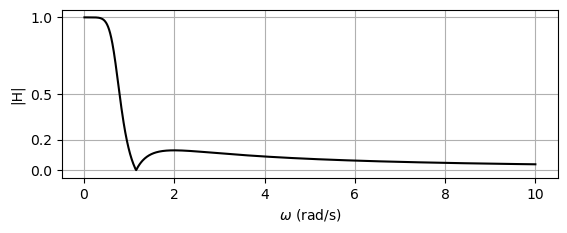

In [15]:
Hs = 0.15
ws = 500
Hp = 0.95
wp = 1e3/ws

wp0 = 1/wp

jj = complex(0,1)

eps = np.sqrt(Hs**2/(1-Hs**2))

aa = sqrt((1/eps**2)*(1/(1-Hp**2)))
bb = (1/np.arccosh(1/wp0))
n = np.arccosh(aa)*bb
print('n =', np.ceil(n))

alpha = 1/eps + sqrt(1 + (1 / eps**2))
print('alpha =', alpha)

a = 0.5 * (alpha**(1/n) - alpha**(-1/n))
b = 0.5 * (alpha**(1/n) + alpha**(-1/n))

print('a =', a, 'b =', b)

p0 = a
d0 = [1, 1/a]

theta = np.deg2rad(60)
p1 = a*cos(theta) + jj*b*sin(theta)
q1 = 1/p1
d1 = [1,2*q1.real,(q1.real**2 + q1.imag**2)]

den = np.convolve(d0, d1)

omega1 = 1/cos(1*pi/(2*3))
num = [0,1,0,omega1**2]

K = den[3]/num[3]
num = [0,K,0,K*omega1**2]

numh = num[::-1]
denh = den[::-1]

a = 500

nums = [numh[0],a*numh[1],(a**2)*numh[2],(a**3)*numh[3]]
dens = [denh[0],a*denh[1],(a**2)*denh[2],(a**3)*denh[3]]

w = np.linspace(0.01, 10, 1000)
system = sig.lti(num, den)
w, Hmag, Hphase = sig.bode(system, n=1000)

plt.subplot(211)
plt.plot(w, 10**(0.05*Hmag), 'k')
#plt.axis([.1*a,3*a, 0, 1.2])
# plt.xticks([.1, .5, .71, 1, 1.25, 2])
plt.yticks([0, .2, .5, 1])
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')